# 12_fidelity_analysis.ipynb

> Fidelity of the generated explanations to the evidence they were given
> Notebooks 08 and 09 measure how far two explanations of the same case stand
> apart. That is a question about stability. This notebook asks the question
> the study is actually organised around: does the generator report the
> evidence it was handed, and does that depend on the generator or the prompt?
> Fidelity appears in 08 only as a conditional mean; here it is estimated with
> case-level cluster bootstrap intervals and paired contrasts, matching the
> inference used for the distance analysis.
> The second half exploits an accident. The first run supplied XGBoost and
> LightGBM SHAP baselines in log-odds beside a predicted probability, so every
> case appeared to sit above the population average. The run was repeated after
> the scale was corrected, and both sets of extractions were kept. The two runs
> differ systematically in one thing only — the overall verdict handed to the
> generator — while the driver list stayed identical. That is a natural
> experiment on whether a generator bends a driver's stated direction to agree
> with the verdict it was given.
> It is a found comparison, not a designed one: the two runs are separate
> generations at temperature 1.0, so ordinary regeneration noise is present in
> every contrast. The within-condition repeat variability is reported alongside
> so the shift can be read against it.

Fidelity rows : 29,700
Generations   : 29,700
Claims        : 137,913

Block B conditions:
llm            prompt      
gpt-5.4-mini   basic           900
               constrained     900
               verification    900
gpt-5.6-luna   basic           900
               constrained     900
               verification    900
gpt-5.6-terra  basic           900
               constrained     900
               verification    900
Saved: tab62_fidelity_with_intervals.csv


,LLM,Prompt,N generations,Omission,Omission CI,Hallucination,Hallucination CI,Direction agreement,Direction agreement CI
0,gpt-5.4-mini,basic,900,0.09133,"[0.0816, 0.1007]",0.00133,"[0.0004, 0.0024]",0.99644,"[0.9942, 0.9983]"
1,gpt-5.4-mini,constrained,900,0.00133,"[0.0000, 0.0033]",0.00000,"[0.0000, 0.0000]",0.99978,"[0.9993, 1.0000]"
2,gpt-5.4-mini,verification,900,0.03756,"[0.0311, 0.0442]",0.00000,"[0.0000, 0.0000]",0.99911,"[0.9982, 0.9998]"
3,gpt-5.6-luna,basic,900,0.03089,"[0.0244, 0.0378]",0.00022,"[0.0000, 0.0007]",0.99856,"[0.9971, 0.9998]"
4,gpt-5.6-luna,constrained,900,0.00000,"[0.0000, 0.0000]",0.00000,"[0.0000, 0.0000]",1.00000,"[1.0000, 1.0000]"
5,gpt-5.6-luna,verification,900,0.00844,"[0.0053, 0.0118]",0.00000,"[0.0000, 0.0000]",0.99889,"[0.9971, 1.0000]"
6,gpt-5.6-terra,basic,900,0.05978,"[0.0511, 0.0687]",0.00074,"[0.0000, 0.0017]",0.99978,"[0.9993, 1.0000]"
7,gpt-5.6-terra,constrained,900,0.00000,"[0.0000, 0.0000]",0.00000,"[0.0000, 0.0000]",1.00000,"[1.0000, 1.0000]"
8,gpt-5.6-terra,verification,900,0.01800,"[0.0133, 0.0227]",0.00000,"[0.0000, 0.0000]",0.99978,"[0.9993, 1.0000]"


Saved: tab63_prompt_contrasts.csv


,LLM,Contrast,Metric,Difference,CI low,CI high,N cases,Excludes zero
0,gpt-5.4-mini,basic - constrained,Omission,0.09000,0.07977,0.10001,300,True
3,gpt-5.4-mini,basic - verification,Omission,0.05378,0.04533,0.06222,300,True
6,gpt-5.4-mini,constrained - verification,Omission,-0.03622,-0.04289,-0.02956,300,True
9,gpt-5.6-luna,basic - constrained,Omission,0.03089,0.02467,0.03800,300,True
12,gpt-5.6-luna,basic - verification,Omission,0.02244,0.01666,0.02822,300,True
15,gpt-5.6-luna,constrained - verification,Omission,-0.00844,-0.01200,-0.00533,300,True
18,gpt-5.6-terra,basic - constrained,Omission,0.05978,0.05133,0.06867,300,True
21,gpt-5.6-terra,basic - verification,Omission,0.04178,0.03399,0.05000,300,True
24,gpt-5.6-terra,constrained - verification,Omission,-0.01800,-0.02289,-0.01355,300,True


Saved: tab64_generator_contrasts.csv


,Prompt,Contrast,Metric,Difference,CI low,CI high,N cases,Excludes zero
0,basic,gpt-5.4-mini - gpt-5.6-luna,Omission,0.06044,0.04956,0.07089,300,True
3,basic,gpt-5.4-mini - gpt-5.6-terra,Omission,0.03156,0.02244,0.04089,300,True
6,basic,gpt-5.6-luna - gpt-5.6-terra,Omission,-0.02889,-0.03711,-0.02111,300,True
9,constrained,gpt-5.4-mini - gpt-5.6-luna,Omission,0.00133,0.00000,0.00333,300,False
12,constrained,gpt-5.4-mini - gpt-5.6-terra,Omission,0.00133,0.00000,0.00333,300,False
15,constrained,gpt-5.6-luna - gpt-5.6-terra,Omission,0.00000,0.00000,0.00000,300,False
18,verification,gpt-5.4-mini - gpt-5.6-luna,Omission,0.02911,0.02177,0.03644,300,True
21,verification,gpt-5.4-mini - gpt-5.6-terra,Omission,0.01956,0.01244,0.02689,300,True
24,verification,gpt-5.6-luna - gpt-5.6-terra,Omission,-0.00956,-0.01489,-0.00467,300,True


Saved: tab65_prompt_by_generator.csv


,Prompt,LLM,Omission change vs basic,CI low,CI high,Excludes zero
0,constrained,gpt-5.4-mini,-0.09000,-0.09978,-0.08022,True
1,constrained,gpt-5.6-luna,-0.03089,-0.03756,-0.02422,True
2,constrained,gpt-5.6-terra,-0.05978,-0.06844,-0.05133,True
3,verification,gpt-5.4-mini,-0.05378,-0.06244,-0.04511,True
4,verification,gpt-5.6-luna,-0.02244,-0.02889,-0.01667,True
5,verification,gpt-5.6-terra,-0.04178,-0.04933,-0.03400,True



Spread of the prompt effect across generators:
Prompt
constrained     0.05911
verification    0.03134
A small spread means prompt design substitutes for model choice; a large one means the recommendation depends on the model.
Saved: fig40_fidelity_with_intervals.png / fig40_fidelity_with_intervals.pdf


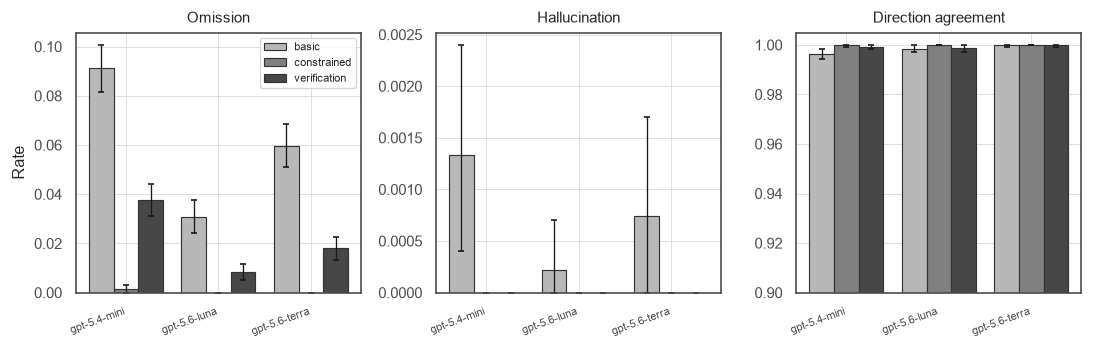

claims_cache_misref: 100%|██████████| 29700/29700 [00:12<00:00, 2447.29it/s]



current run : 29,700
first run   : 29,700
Paired generations: 29,700
affected_old
unaffected     9600
affected      20100

Unaffected conditions identical across runs: 1.0000  (1.0000 confirms correct pairing)
Saved: tab66_within_condition_repeat_noise.csv


,LLM,Prompt,Metric,Within-case SD across repeats
2,gpt-5.4-mini,basic,Direction agreement,0.00529
5,gpt-5.4-mini,constrained,Direction agreement,0.00038
8,gpt-5.4-mini,verification,Direction agreement,0.00154
11,gpt-5.6-luna,basic,Direction agreement,0.00208
14,gpt-5.6-luna,constrained,Direction agreement,0.00000
17,gpt-5.6-luna,verification,Direction agreement,0.00077
20,gpt-5.6-terra,basic,Direction agreement,0.00038
23,gpt-5.6-terra,constrained,Direction agreement,0.00000
26,gpt-5.6-terra,verification,Direction agreement,0.00038


Saved: tab67_baseline_scale_natural_experiment.csv
Direction agreement, first run versus corrected run:


,Block,LLM,Prompt,Metric,First run,Corrected run,Change,CI low,CI high,N cases,Excludes zero
26,B,gpt-5.6-terra,basic,Direction agreement,0.95017,0.99978,0.05578,0.03489,0.07811,300,True
41,C,gpt-5.6-terra,basic,Direction agreement,0.96942,1.00000,0.03133,0.01133,0.05417,100,True
50,D,gpt-5.6-terra,basic,Direction agreement,0.97389,1.00000,0.02763,0.00550,0.05787,60,True
59,D0,gpt-5.6-terra,basic,Direction agreement,0.97791,1.00000,0.02298,0.00183,0.04821,60,True
32,B,gpt-5.6-terra,verification,Direction agreement,0.99444,0.99978,0.00533,0.00089,0.01022,300,True
35,C,gpt-5.4-mini,basic,Direction agreement,0.99338,0.99838,0.00500,0.00000,0.01087,100,False
5,A_prime,gpt-5.4-mini,basic,Direction agreement,0.98750,0.99197,0.00447,0.00191,0.00735,300,True
53,D0,gpt-5.4-mini,basic,Direction agreement,0.99360,0.99683,0.00324,-0.00275,0.00858,60,False
2,A,gpt-5.4-mini,basic,Direction agreement,0.99052,0.99356,0.00304,-0.00053,0.00721,300,False
20,B,gpt-5.6-luna,constrained,Direction agreement,0.99778,1.00000,0.00222,0.00000,0.00556,300,False


...

Saved: tab69_reversal_rate_by_verdict_conflict.csv


,Run,Driver opposed the shown verdict,Flip rate,N claims
0,corrected run,False,0.00210,67299
1,corrected run,True,0.00240,27962
2,first run,False,0.00478,49989
3,first run,True,0.01219,46087


Saved: tab70_top_driver_reversal_by_verdict_conflict.csv

Rank-1 drivers only:


,Run,Top driver opposed the shown verdict,Flip rate,N claims
0,corrected run,False,0.00057,17528
1,corrected run,True,0.01873,1548
2,first run,False,0.00258,12421
3,first run,True,0.01836,7025



Share of first-run claims whose case was actually below average, and so mis-presented: 0.3462
Saved: fig41_baseline_scale_natural_experiment.png / fig41_baseline_scale_natural_experiment.pdf


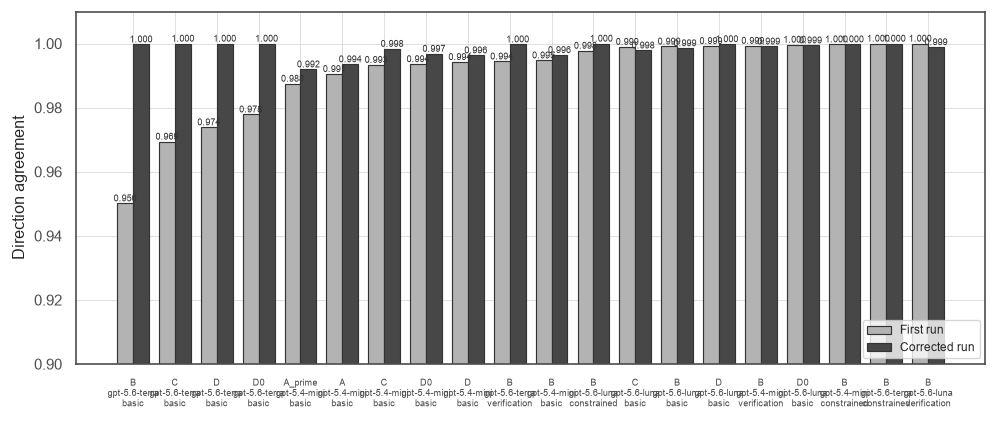

Saved: fig42_reversal_mechanism.png / fig42_reversal_mechanism.pdf


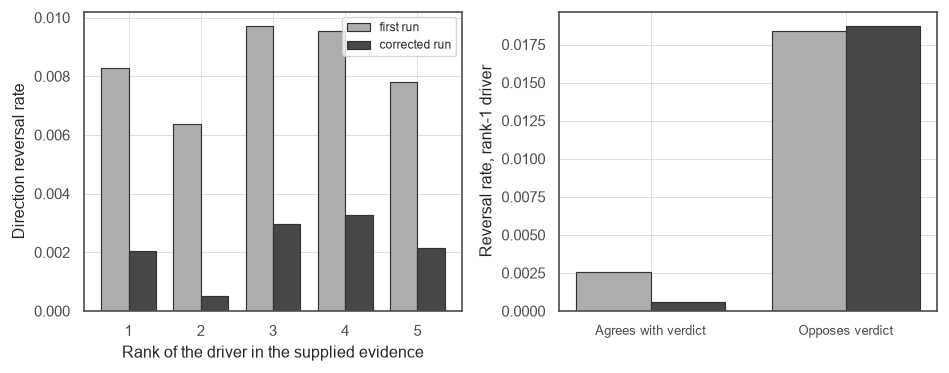

Saved: fidelity_manifest.json
Saved: logs/12_run_20261001.json
Outputs:
  results\tables\tab62_fidelity_with_intervals.csv
  results\tables\tab63_prompt_contrasts.csv
  results\tables\tab64_generator_contrasts.csv
  results\tables\tab65_prompt_by_generator.csv
  results\tables\tab66_within_condition_repeat_noise.csv
  results\tables\tab67_baseline_scale_natural_experiment.csv
  results\tables\tab68_reversal_rate_by_evidence_rank.csv
  results\tables\tab69_reversal_rate_by_verdict_conflict.csv
  results\tables\tab70_top_driver_reversal_by_verdict_conflict.csv
  results\figures\fig40_fidelity_with_intervals.pdf
  results\figures\fig40_fidelity_with_intervals.png
  results\figures\fig41_baseline_scale_natural_experiment.pdf
  results\figures\fig41_baseline_scale_natural_experiment.png
  results\figures\fig42_reversal_mechanism.pdf
  results\figures\fig42_reversal_mechanism.png
  results\figures\fig42_reversal_rate_by_rank.pdf
  results\figures\fig42_reversal_rate_by_rank.png

Reporting no

In [2]:
# ============================================================================
# 12_fidelity_analysis.ipynb
# Fidelity of the generated explanations to the evidence they were given
#
# Notebooks 08 and 09 measure how far two explanations of the same case stand
# apart. That is a question about stability. This notebook asks the question
# the study is actually organised around: does the generator report the
# evidence it was handed, and does that depend on the generator or the prompt?
# Fidelity appears in 08 only as a conditional mean; here it is estimated with
# case-level cluster bootstrap intervals and paired contrasts, matching the
# inference used for the distance analysis.
#
# The second half exploits an accident. The first run supplied XGBoost and
# LightGBM SHAP baselines in log-odds beside a predicted probability, so every
# case appeared to sit above the population average. The run was repeated after
# the scale was corrected, and both sets of extractions were kept. The two runs
# differ systematically in one thing only — the overall verdict handed to the
# generator — while the driver list stayed identical. That is a natural
# experiment on whether a generator bends a driver's stated direction to agree
# with the verdict it was given.
#
# It is a found comparison, not a designed one: the two runs are separate
# generations at temperature 1.0, so ordinary regeneration noise is present in
# every contrast. The within-condition repeat variability is reported alongside
# so the shift can be read against it.
# ============================================================================


# [Cell 1] Imports and global configuration
import json
import warnings
from pathlib import Path
from itertools import combinations
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

SEED = 42
rng_global = np.random.default_rng(SEED)

ROOT = Path("..")
DATA_DIR = ROOT / "data"
FIG_DIR = ROOT / "results" / "figures"
TAB_DIR = ROOT / "results" / "tables"
LOG_DIR = ROOT / "logs"

for d in [DATA_DIR, FIG_DIR, TAB_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)


# [Cell 2] Plotting style: grayscale, publication settings
sns.set_theme(style="whitegrid", context="paper")
sns.set_palette(sns.color_palette("gray", n_colors=8))

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "font.family": "sans-serif",
    "axes.grid": True,
    "grid.color": "0.85",
    "grid.linewidth": 0.5,
    "axes.edgecolor": "0.3",
    "axes.labelcolor": "0.15",
    "text.color": "0.15",
    "xtick.color": "0.3",
    "ytick.color": "0.3",
    "image.cmap": "gray",
    "savefig.bbox": "tight",
    "savefig.transparent": False,
})


def save_fig(fig, name):
    """Save a figure as both PNG and PDF at 600 dpi. No caption is added."""
    for ext in ["png", "pdf"]:
        fig.savefig(FIG_DIR / f"{name}.{ext}", dpi=600, bbox_inches="tight")
    print(f"Saved: {name}.png / {name}.pdf")


def save_table(df, name, index=False):
    """Save a table as CSV under results/tables."""
    df.to_csv(TAB_DIR / f"{name}.csv", index=index, encoding="utf-8-sig")
    print(f"Saved: {name}.csv")


# [Cell 3] Analysis configuration
B_BOOTSTRAP = 2000
CI_LEVEL = 0.95
MIN_CASES = 30

# Block B is the fidelity block: the evidence is fixed at XGBoost + SHAP and
# only the generator and the prompt vary, so any difference in fidelity is
# attributable to the generation stage.
FIDELITY_BLOCK = "B"

METRICS = ["omission_rate", "hallucination_rate", "direction_agreement"]
METRIC_LABELS = {
    "omission_rate": "Omission",
    "hallucination_rate": "Hallucination",
    "direction_agreement": "Direction agreement",
}

# Conditions whose baseline was mis-scaled in the first run
AFFECTED = {"XGBoost", "LightGBM"}


# [Cell 4] Load the current run
fidelity = pd.read_parquet(DATA_DIR / "fidelity.parquet")
corpus = pd.read_parquet(DATA_DIR / "generation_corpus.parquet")
claims_long = pd.read_parquet(DATA_DIR / "claims_long.parquet")

print(f"Fidelity rows : {len(fidelity):,}")
print(f"Generations   : {len(corpus):,}")
print(f"Claims        : {len(claims_long):,}")
print(f"\nBlock {FIDELITY_BLOCK} conditions:")
print(fidelity[fidelity["block"] == FIDELITY_BLOCK]
      .groupby(["llm", "prompt"]).size().to_string())


# [Cell 5] Case-level cluster bootstrap
# Cases are the resampling unit throughout, as in 09. A generation is not an
# independent observation: the three repeats of a condition share a case, and
# the nine condition cells share it too.
def cluster_bootstrap_mean(df, col, cluster="case_id",
                           B=B_BOOTSTRAP, level=CI_LEVEL, rng=None):
    """Percentile interval for a mean, resampling whole cases."""
    rng = rng or np.random.default_rng(SEED)
    valid = df[[col, cluster]].dropna()
    if valid[cluster].nunique() < MIN_CASES:
        return {"estimate": np.nan, "ci_low": np.nan, "ci_high": np.nan,
                "n_cases": valid[cluster].nunique(), "n_obs": len(valid)}

    groups = {c: g[col].to_numpy() for c, g in valid.groupby(cluster)}
    cases = np.array(list(groups))
    point = float(np.nanmean(valid[col].to_numpy()))

    stats = np.empty(B)
    for i in range(B):
        picked = rng.choice(cases, size=len(cases), replace=True)
        stats[i] = np.nanmean(np.concatenate([groups[c] for c in picked]))

    a = (1 - level) / 2
    return {
        "estimate": round(point, 5),
        "ci_low": round(float(np.nanquantile(stats, a)), 5),
        "ci_high": round(float(np.nanquantile(stats, 1 - a)), 5),
        "n_cases": len(cases),
        "n_obs": len(valid),
    }


def cluster_bootstrap_paired(df_a, df_b, col, cluster="case_id",
                             B=B_BOOTSTRAP, level=CI_LEVEL, rng=None):
    """Interval for a difference, resampling the cases the two conditions share.

    The same resampled case index is applied to both sides, so the pairing that
    makes this a within-case contrast survives resampling.
    """
    rng = rng or np.random.default_rng(SEED)
    a = df_a[[col, cluster]].dropna().groupby(cluster)[col].mean()
    b = df_b[[col, cluster]].dropna().groupby(cluster)[col].mean()
    shared = a.index.intersection(b.index)
    if len(shared) < MIN_CASES:
        return None

    diff = (a.loc[shared] - b.loc[shared]).to_numpy()
    cases = np.arange(len(shared))
    point = float(diff.mean())

    stats = np.empty(B)
    for i in range(B):
        stats[i] = diff[rng.choice(cases, size=len(cases), replace=True)].mean()

    lo = float(np.quantile(stats, (1 - level) / 2))
    hi = float(np.quantile(stats, 1 - (1 - level) / 2))
    return {
        "difference": round(point, 5),
        "ci_low": round(lo, 5),
        "ci_high": round(hi, 5),
        "n_cases": len(shared),
        "excludes_zero": bool(lo > 0 or hi < 0),
    }


# [Cell 6] Fidelity by generator and prompt, with intervals
# The headline table for the study's main question. Evidence is identical
# across every row, so the spread is the generation stage alone.
block = fidelity[fidelity["block"] == FIDELITY_BLOCK]
rng = np.random.default_rng(SEED)

rows = []
for (llm, prompt), g in block.groupby(["llm", "prompt"]):
    row = {"LLM": llm, "Prompt": prompt, "N generations": len(g)}
    for m in METRICS:
        res = cluster_bootstrap_mean(g, m, rng=rng)
        row[METRIC_LABELS[m]] = res["estimate"]
        row[f"{METRIC_LABELS[m]} CI"] = f"[{res['ci_low']:.4f}, {res['ci_high']:.4f}]"
    rows.append(row)

fidelity_ci = pd.DataFrame(rows).sort_values(["LLM", "Prompt"])
save_table(fidelity_ci, "tab62_fidelity_with_intervals")
display(fidelity_ci)


# [Cell 7] Prompt contrasts, paired within case
# Every prompt condition was run on the same 300 cases with the same evidence,
# so the comparison is paired and the between-case variance drops out.
rng = np.random.default_rng(SEED + 1)
rows = []

for llm, g in block.groupby("llm"):
    prompts = sorted(g["prompt"].unique())
    for p_a, p_b in combinations(prompts, 2):
        for m in METRICS:
            res = cluster_bootstrap_paired(
                g[g["prompt"] == p_a], g[g["prompt"] == p_b], m, rng=rng
            )
            if res is None:
                continue
            rows.append({
                "LLM": llm,
                "Contrast": f"{p_a} - {p_b}",
                "Metric": METRIC_LABELS[m],
                "Difference": res["difference"],
                "CI low": res["ci_low"],
                "CI high": res["ci_high"],
                "N cases": res["n_cases"],
                "Excludes zero": res["excludes_zero"],
            })

prompt_contrasts = pd.DataFrame(rows)
save_table(prompt_contrasts, "tab63_prompt_contrasts")
display(prompt_contrasts[prompt_contrasts["Metric"] == "Omission"])


# [Cell 8] Generator contrasts, paired within case
rng = np.random.default_rng(SEED + 2)
rows = []

for prompt, g in block.groupby("prompt"):
    llms = sorted(g["llm"].unique())
    for l_a, l_b in combinations(llms, 2):
        for m in METRICS:
            res = cluster_bootstrap_paired(
                g[g["llm"] == l_a], g[g["llm"] == l_b], m, rng=rng
            )
            if res is None:
                continue
            rows.append({
                "Prompt": prompt,
                "Contrast": f"{l_a} - {l_b}",
                "Metric": METRIC_LABELS[m],
                "Difference": res["difference"],
                "CI low": res["ci_low"],
                "CI high": res["ci_high"],
                "N cases": res["n_cases"],
                "Excludes zero": res["excludes_zero"],
            })

llm_contrasts = pd.DataFrame(rows)
save_table(llm_contrasts, "tab64_generator_contrasts")
display(llm_contrasts[llm_contrasts["Metric"] == "Omission"])


# [Cell 9] Does the prompt help every generator equally
# If the constrained prompt closes the gap between generators, prompt design
# substitutes for model capability; if it helps some more than others, the two
# interact and a recommendation has to name the model.
rng = np.random.default_rng(SEED + 3)
rows = []

base_prompt = "basic"
for target in [p for p in sorted(block["prompt"].unique()) if p != base_prompt]:
    for llm, g in block.groupby("llm"):
        res = cluster_bootstrap_paired(
            g[g["prompt"] == target], g[g["prompt"] == base_prompt],
            "omission_rate", rng=rng,
        )
        if res is None:
            continue
        rows.append({
            "Prompt": target,
            "LLM": llm,
            "Omission change vs basic": res["difference"],
            "CI low": res["ci_low"],
            "CI high": res["ci_high"],
            "Excludes zero": res["excludes_zero"],
        })

interaction = pd.DataFrame(rows)
save_table(interaction, "tab65_prompt_by_generator")
display(interaction)

if len(interaction):
    spread = (
        interaction.groupby("Prompt")["Omission change vs basic"]
        .agg(lambda s: s.max() - s.min())
    )
    print("\nSpread of the prompt effect across generators:")
    print(spread.round(5).to_string())
    print("A small spread means prompt design substitutes for model choice; "
          "a large one means the recommendation depends on the model.")


# [Cell 10] Figure: fidelity by generator and prompt
fig, axes = plt.subplots(1, 3, figsize=(9.2, 3.0))

llms = sorted(block["llm"].unique())
prompts = sorted(block["prompt"].unique())
shades = ["0.72", "0.50", "0.28"]
x = np.arange(len(llms))
width = 0.8 / max(len(prompts), 1)

for ax, m in zip(axes, METRICS):
    for i, p in enumerate(prompts):
        vals, errs = [], [[], []]
        for llm in llms:
            row = fidelity_ci[(fidelity_ci["LLM"] == llm)
                              & (fidelity_ci["Prompt"] == p)]
            if len(row) == 0:
                vals.append(np.nan)
                errs[0].append(0)
                errs[1].append(0)
                continue
            v = float(row[METRIC_LABELS[m]].iloc[0])
            lo, hi = [float(t) for t in
                      row[f"{METRIC_LABELS[m]} CI"].iloc[0].strip("[]").split(",")]
            vals.append(v)
            errs[0].append(max(v - lo, 0))
            errs[1].append(max(hi - v, 0))

        pos = x + (i - (len(prompts) - 1) / 2) * width
        ax.bar(pos, vals, width, color=shades[i % 3],
               edgecolor="0.2", linewidth=0.7, label=p)
        ax.errorbar(pos, vals, yerr=errs, fmt="none",
                    ecolor="0.1", elinewidth=0.8, capsize=2)

    ax.set_xticks(x)
    ax.set_xticklabels(llms, fontsize=6.5, rotation=20, ha="right")
    ax.set_title(METRIC_LABELS[m], fontsize=9, color="0.15")
    if m == "direction_agreement":
        ax.set_ylim(0.9, 1.005)
    else:
        ax.set_ylim(0, None)
    if m == METRICS[0]:
        ax.set_ylabel("Rate")
        ax.legend(fontsize=6.5, frameon=True, loc="upper right")

plt.tight_layout()
save_fig(fig, "fig40_fidelity_with_intervals")
plt.show()


# [Cell 11] Load the first run for the natural experiment
# Both runs are read from their claim caches rather than recomputed, so the
# comparison uses exactly the extractions each analysis was built on.
def fidelity_from_cache(folder):
    """Recompute per-generation fidelity from a claims cache directory."""
    path = DATA_DIR / folder
    files = sorted(path.glob("*.json"))
    if not files:
        raise FileNotFoundError(f"No cached extractions under {path}")

    rows = []
    for p in tqdm(files, desc=folder):
        rec = json.loads(p.read_text(encoding="utf-8"))
        supplied = {d["feature"]: d["direction"] for d in rec["evidence"]}
        claimed = {c["feature"]: c["direction"] for c in rec["claims"]}

        common = set(supplied) & set(claimed)
        resolved = [f for f in common if claimed[f] is not None]

        rows.append({
            "block": rec["block"], "domain": rec["domain"], "model": rec["model"],
            "xai": rec["xai"], "llm": rec["llm"], "prompt": rec["prompt"],
            "case_id": rec["case_id"], "repeat": rec["repeat"],
            "omission_rate": 1 - len(common) / len(supplied) if supplied else np.nan,
            "hallucination_rate": (
                len(set(claimed) - set(supplied)) / len(claimed) if claimed else np.nan
            ),
            "direction_agreement": (
                float(np.mean([claimed[f] == supplied[f] for f in resolved]))
                if resolved else np.nan
            ),
        })
    return pd.DataFrame(rows)


fid_new = fidelity_from_cache("claims_cache")
fid_old = fidelity_from_cache("claims_cache_misref")

KEY = ["block", "domain", "model", "xai", "llm", "prompt", "case_id", "repeat"]
print(f"\ncurrent run : {len(fid_new):,}")
print(f"first run   : {len(fid_old):,}")


# [Cell 12] Split by whether the condition was affected
# The correction changed the baseline only for XGBoost and LightGBM under SHAP.
# Everything else was never regenerated, so those cached extractions are the
# same files in both directories. Their contrast is expected to be exactly
# zero and serves as a check that the two runs are being paired correctly,
# not as a statistical control.
for f in (fid_new, fid_old):
    f["affected"] = (f["model"].isin(AFFECTED)) & (f["xai"] == "SHAP")

paired = fid_old.merge(fid_new, on=KEY, suffixes=("_old", "_new"))
print(f"Paired generations: {len(paired):,}")
print(paired.groupby("affected_old").size().rename(
    index={True: "affected", False: "unaffected"}).to_string())

check = paired[~paired["affected_old"]]
identical = np.isclose(
    check["direction_agreement_old"].fillna(-1),
    check["direction_agreement_new"].fillna(-1),
).mean() if len(check) else np.nan
print(f"\nUnaffected conditions identical across runs: {identical:.4f}  "
      f"(1.0000 confirms correct pairing)")


# [Cell 13] Within-condition repeat variability, for reference
# The two runs are separate generations at temperature 1.0, so any contrast
# between them contains ordinary regeneration noise. This is how large that
# noise is on the same metrics, measured inside the current run.
noise_rows = []
for (llm, prompt), g in fid_new[
    (fid_new["block"] == FIDELITY_BLOCK)
].groupby(["llm", "prompt"]):
    for m in METRICS:
        per_case_sd = g.groupby("case_id")[m].std()
        noise_rows.append({
            "LLM": llm, "Prompt": prompt, "Metric": METRIC_LABELS[m],
            "Within-case SD across repeats": round(float(per_case_sd.mean()), 5),
        })

repeat_noise = pd.DataFrame(noise_rows)
save_table(repeat_noise, "tab66_within_condition_repeat_noise")
display(repeat_noise[repeat_noise["Metric"] == "Direction agreement"])


# [Cell 14] The natural experiment
# Same evidence, same generator, same prompt, same case. The runs differ in the
# population reference the generator was shown: a log-odds value in the first
# run, which made every case look above average, and the correct probability in
# the second.
#
# Grouping by generator and prompt alone would pool blocks and domains. case_id
# is a test-set row index, so credit and churn ids collide, and D repeats each
# case twenty times against B's three, which makes a generation-weighted mean
# disagree with the case-weighted contrast beside it. Blocks are kept separate
# and the cluster is scoped to its domain.
affected = paired[paired["affected_old"]].copy()
affected["cluster"] = affected["domain"] + ":" + affected["case_id"].astype(str)
rng = np.random.default_rng(SEED + 4)

rows = []
for (blk, llm, prompt), g in affected.groupby(["block", "llm", "prompt"]):
    if g["cluster"].nunique() < MIN_CASES:
        continue
    for m in METRICS:
        old = g[[f"{m}_old", "cluster"]].rename(columns={f"{m}_old": m})
        new = g[[f"{m}_new", "cluster"]].rename(columns={f"{m}_new": m})
        res = cluster_bootstrap_paired(new, old, m, cluster="cluster", rng=rng)
        if res is None:
            continue
        rows.append({
            "Block": blk,
            "LLM": llm,
            "Prompt": prompt,
            "Metric": METRIC_LABELS[m],
            "First run": round(float(g[f"{m}_old"].mean()), 5),
            "Corrected run": round(float(g[f"{m}_new"].mean()), 5),
            "Change": res["difference"],
            "CI low": res["ci_low"],
            "CI high": res["ci_high"],
            "N cases": res["n_cases"],
            "Excludes zero": res["excludes_zero"],
        })

run_contrast = pd.DataFrame(rows)
save_table(run_contrast, "tab67_baseline_scale_natural_experiment")

print("Direction agreement, first run versus corrected run:")
display(run_contrast[run_contrast["Metric"] == "Direction agreement"]
        .sort_values("Change", ascending=False))


# [Cell 15] Where the reversals sat
# If the generator was resolving a conflict between the verdict it was given
# and the drivers it was shown, the reversals should fall on the drivers that
# contradict the verdict, and most visibly on the highest-ranked one.
def flips_from_cache(folder, label):
    """Direction reversals against the supplied evidence, with their rank."""
    rows = []
    for p in tqdm(sorted((DATA_DIR / folder).glob("*.json")), desc=label):
        rec = json.loads(p.read_text(encoding="utf-8"))
        if not (rec["model"] in AFFECTED and rec["xai"] == "SHAP"):
            continue
        supplied = {d["feature"]: (d["direction"], d["rank"]) for d in rec["evidence"]}
        for c in rec["claims"]:
            ev = supplied.get(c["feature"])
            if ev is None or c["direction"] is None:
                continue
            rows.append({
                "run": label,
                "block": rec["block"], "domain": rec["domain"],
                "model": rec["model"], "xai": rec["xai"],
                "llm": rec["llm"], "prompt": rec["prompt"],
                "case_id": rec["case_id"],
                "evidence_rank": ev[1],
                "flipped": c["direction"] != ev[0],
                "evidence_direction": ev[0],
            })
    return pd.DataFrame(rows)


flips_old = flips_from_cache("claims_cache_misref", "first run")
flips_new = flips_from_cache("claims_cache", "corrected run")
flips = pd.concat([flips_old, flips_new], ignore_index=True)

by_rank = (
    flips.groupby(["run", "evidence_rank"])["flipped"]
    .agg(["mean", "size"])
    .round(5)
    .reset_index()
    .rename(columns={"mean": "Flip rate", "size": "N claims"})
)
save_table(by_rank, "tab68_reversal_rate_by_evidence_rank")
display(by_rank)


# [Cell 16] Reversals against the direction of the verdict
# The label has to mean the same thing in both runs. In the first run the shown
# reference was negative, so the generator was told every case sat above the
# population average and a decreasing driver always contradicted that. In the
# corrected run the verdict follows the case, so the conflict has to be
# computed against the predicted probability the generator was actually shown.
verdict_ref = (
    corpus[["domain", "model", "xai", "case_id",
            "predicted_probability", "base_value"]]
    .drop_duplicates(subset=["domain", "model", "xai", "case_id"])
    .copy()
)
verdict_ref["true_verdict"] = np.where(
    verdict_ref["predicted_probability"] > verdict_ref["base_value"],
    "increases", "decreases",
)

flips = flips.merge(
    verdict_ref[["domain", "model", "xai", "case_id", "true_verdict"]],
    on=["domain", "model", "xai", "case_id"], how="left",
)

# The first run presented every case as above average, whatever it actually was.
flips["shown_verdict"] = np.where(
    flips["run"] == "first run", "increases", flips["true_verdict"]
)
flips["against_verdict"] = flips["evidence_direction"] != flips["shown_verdict"]

unmatched = flips["true_verdict"].isna().sum()
if unmatched:
    print(f"WARNING: {unmatched:,} claims could not be matched to a verdict "
          f"and are excluded from the conflict tables.")
    flips = flips[flips["true_verdict"].notna()]

verdict_rows = []
for (run, against), g in flips.groupby(["run", "against_verdict"]):
    verdict_rows.append({
        "Run": run,
        "Driver opposed the shown verdict": bool(against),
        "Flip rate": round(float(g["flipped"].mean()), 5),
        "N claims": len(g),
    })

by_verdict = pd.DataFrame(verdict_rows)
save_table(by_verdict, "tab69_reversal_rate_by_verdict_conflict")
display(by_verdict)

top = flips[flips["evidence_rank"] == 1]
top_rows = []
for (run, against), g in top.groupby(["run", "against_verdict"]):
    top_rows.append({
        "Run": run,
        "Top driver opposed the shown verdict": bool(against),
        "Flip rate": round(float(g["flipped"].mean()), 5),
        "N claims": len(g),
    })
by_verdict_top = pd.DataFrame(top_rows)
save_table(by_verdict_top, "tab70_top_driver_reversal_by_verdict_conflict")
print("\nRank-1 drivers only:")
display(by_verdict_top)

# How often the shown verdict was wrong in the first run, which is the
# exposure the comparison rests on.
first = flips[flips["run"] == "first run"]
if len(first):
    wrong = (first["true_verdict"] == "decreases").mean()
    print(f"\nShare of first-run claims whose case was actually below average, "
          f"and so mis-presented: {wrong:.4f}")


# [Cell 17] Figure: the two runs compared
if len(run_contrast):
    sub = run_contrast[run_contrast["Metric"] == "Direction agreement"].copy()
    sub["label"] = sub["Block"] + "\n" + sub["LLM"] + "\n" + sub["Prompt"]
    sub = sub.sort_values("First run")

    fig, ax = plt.subplots(figsize=(8.4, 3.6))
    x = np.arange(len(sub))
    width = 0.38

    ax.bar(x - width / 2, sub["First run"], width,
           color="0.70", edgecolor="0.2", linewidth=0.7, label="First run")
    ax.bar(x + width / 2, sub["Corrected run"], width,
           color="0.28", edgecolor="0.2", linewidth=0.7, label="Corrected run")

    for xi, v in zip(x - width / 2, sub["First run"]):
        ax.text(xi, v, f"{v:.3f}", ha="center", va="bottom", fontsize=5.5, color="0.2")
    for xi, v in zip(x + width / 2, sub["Corrected run"]):
        ax.text(xi, v, f"{v:.3f}", ha="center", va="bottom", fontsize=5.5, color="0.2")

    ax.set_xticks(x)
    ax.set_xticklabels(sub["label"], fontsize=5.5)
    ax.set_ylabel("Direction agreement")
    ax.set_ylim(0.9, 1.01)
    ax.legend(fontsize=7, frameon=True, loc="lower right")

    plt.tight_layout()
    save_fig(fig, "fig41_baseline_scale_natural_experiment")
    plt.show()


# [Cell 18] Figure: reversal rate by rank and by verdict conflict
fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.2))

runs = ["first run", "corrected run"]
shades = {"first run": "0.68", "corrected run": "0.28"}

ax = axes[0]
ranks = sorted(by_rank["evidence_rank"].unique())
x = np.arange(len(ranks))
width = 0.38
for i, run in enumerate(runs):
    s = by_rank[by_rank["run"] == run].set_index("evidence_rank").reindex(ranks)
    ax.bar(x + (i - 0.5) * width, s["Flip rate"], width,
           color=shades[run], edgecolor="0.2", linewidth=0.7, label=run)
ax.set_xticks(x)
ax.set_xticklabels([f"{int(r)}" for r in ranks])
ax.set_xlabel("Rank of the driver in the supplied evidence")
ax.set_ylabel("Direction reversal rate")
ax.legend(fontsize=7, frameon=True, loc="upper right")

ax = axes[1]
labels = ["Agrees with verdict", "Opposes verdict"]
x = np.arange(len(labels))
for i, run in enumerate(runs):
    vals = []
    for against in [False, True]:
        row = by_verdict_top[(by_verdict_top["Run"] == run)
                             & (by_verdict_top["Top driver opposed the shown verdict"]
                                == against)]
        vals.append(float(row["Flip rate"].iloc[0]) if len(row) else np.nan)
    ax.bar(x + (i - 0.5) * width, vals, width,
           color=shades[run], edgecolor="0.2", linewidth=0.7, label=run)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("Reversal rate, rank-1 driver")

plt.tight_layout()
save_fig(fig, "fig42_reversal_mechanism")
plt.show()


# [Cell 19] Summary
summary = {
    "notebook": "12_fidelity_analysis",
    "timestamp": pd.Timestamp.now().isoformat(),
    "seed": SEED,
    "bootstrap_draws": B_BOOTSTRAP,
    "fidelity_block": FIDELITY_BLOCK,
    "fidelity_with_intervals": fidelity_ci.to_dict(orient="records"),
    "prompt_contrasts": prompt_contrasts.to_dict(orient="records"),
    "generator_contrasts": llm_contrasts.to_dict(orient="records"),
    "prompt_by_generator": interaction.to_dict(orient="records"),
    "repeat_noise": repeat_noise.to_dict(orient="records"),
    "natural_experiment": run_contrast.to_dict(orient="records"),
    "reversal_by_rank": by_rank.to_dict(orient="records"),
    "reversal_by_verdict": by_verdict.to_dict(orient="records"),
    "reversal_by_verdict_top_driver": by_verdict_top.to_dict(orient="records"),
}

with open(DATA_DIR / "fidelity_manifest.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2, default=str)
print("Saved: fidelity_manifest.json")

stamp = pd.Timestamp.now().strftime("%Y%m%d")
with open(LOG_DIR / f"12_run_{stamp}.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2, default=str)
print(f"Saved: logs/12_run_{stamp}.json")


# [Cell 20] Verification and reporting notes
print("Outputs:")
for p in sorted(TAB_DIR.glob("tab6[2-9]*")) + sorted(TAB_DIR.glob("tab70*")) \
        + sorted(FIG_DIR.glob("fig4[0-2]*")):
    print(f"  {p.relative_to(ROOT)}")

print("""
Reporting notes
  - Block B holds the evidence fixed, so the fidelity differences in tab62 to
    tab65 are attributable to the generation stage alone. Report them as the
    study's primary result, with the distance analysis in 09 as the account of
    what those differences do to explanation content.

  - The run comparison in tab67 is a found contrast, not a designed condition.
    Say so plainly in the paper: a scale error in the first run supplied a
    population reference in log-odds beside a predicted probability, so every
    case appeared above average; the run was repeated after correction and both
    extraction sets were retained. The driver lists were identical across runs.

  - The two runs are separate generations at temperature 1.0, so every contrast
    in tab67 also contains ordinary regeneration noise. tab66 gives the size of
    that noise on the same metrics, measured within the corrected run. A change
    that is large relative to it is attributable to the corrected reference;
    one that is not should not be.

  - tab68 to tab70 test the mechanism rather than the effect. The conflict
    label is computed against the verdict each run actually showed the
    generator, not against a fixed direction, so the two runs are comparable.
    If the generator was reconciling a contradictory verdict with the drivers
    in front of it, reversals should concentrate on drivers that opposed the
    shown verdict and should subside once the verdict is correct.
""")

In [3]:
# The conflict propensity in tab70 pools the generators. tab67 showed the run
# effect concentrated on one of them, so the propensity is split out here to
# see whether the behaviour is model-specific or general.
top = flips[flips["evidence_rank"] == 1]
rows = []
for (run, llm, against), g in top.groupby(["run", "llm", "against_verdict"]):
    rows.append({
        "Run": run,
        "LLM": llm,
        "Top driver opposed verdict": bool(against),
        "Flip rate": round(float(g["flipped"].mean()), 5),
        "N claims": len(g),
    })

by_llm = pd.DataFrame(rows)
save_table(by_llm, "tab71_top_driver_reversal_by_generator")
display(by_llm.sort_values(["Top driver opposed verdict", "Run", "LLM"]))

# Exposure is what changed between runs; the propensity is what the generator
# contributes. Reporting them apart keeps the two from being confused.
expo = (
    top.groupby(["run", "llm"])["against_verdict"].mean()
    .round(4).rename("Share of rank-1 drivers opposing the verdict")
)
print("\n" + expo.to_string())

Saved: tab71_top_driver_reversal_by_generator.csv


,Run,LLM,Top driver opposed verdict,Flip rate,N claims
0,corrected run,gpt-5.4-mini,False,0.00013,7615
2,corrected run,gpt-5.6-luna,False,0.00178,5054
4,corrected run,gpt-5.6-terra,False,0.00000,4859
6,first run,gpt-5.4-mini,False,0.00582,5498
8,first run,gpt-5.6-luna,False,0.00000,3494
10,first run,gpt-5.6-terra,False,0.00000,3429
1,corrected run,gpt-5.4-mini,True,0.03537,735
3,corrected run,gpt-5.6-luna,True,0.00737,407
5,corrected run,gpt-5.6-terra,True,0.00000,406
7,first run,gpt-5.4-mini,True,0.00096,3113



run            llm          
corrected run  gpt-5.4-mini     0.0880
               gpt-5.6-luna     0.0745
               gpt-5.6-terra    0.0771
first run      gpt-5.4-mini     0.3615
               gpt-5.6-luna     0.3602
               gpt-5.6-terra    0.3619


In [4]:
# The first run showed every case as above average, but 34.6 per cent were not.
# Its "conflict" label therefore mixes genuine tension with cases where the
# driver agreed with reality and only disagreed with a fabricated verdict.
# Stratifying by the true verdict separates them: where the first run happened
# to show the correct verdict it is a placebo, and the treatment is confined to
# the cases it misrepresented.
top = flips[flips["evidence_rank"] == 1].copy()
top["shown_correctly"] = top["true_verdict"] == "increases"

rows = []
for (run, llm, correct), g in top.groupby(["run", "llm", "shown_correctly"]):
    rows.append({
        "Run": run,
        "LLM": llm,
        "Verdict shown correctly in run 1": bool(correct),
        "Flip rate": round(float(g["flipped"].mean()), 5),
        "N claims": len(g),
    })

did = pd.DataFrame(rows)
save_table(did, "tab72_reversal_difference_in_differences")
display(did.sort_values(["LLM", "Verdict shown correctly in run 1", "Run"]))

# The contrast of contrasts: how much more the reversal rate fell where the
# first run had misrepresented the verdict than where it had not.
print("\nChange from first run to corrected run, by stratum:")
for llm in sorted(top["llm"].unique()):
    line = {}
    for correct in [True, False]:
        a = did[(did["LLM"] == llm) & (did["Run"] == "first run")
                & (did["Verdict shown correctly in run 1"] == correct)]
        b = did[(did["LLM"] == llm) & (did["Run"] == "corrected run")
                & (did["Verdict shown correctly in run 1"] == correct)]
        if len(a) and len(b):
            line[correct] = float(b["Flip rate"].iloc[0]) - float(a["Flip rate"].iloc[0])
    if len(line) == 2:
        print(f"  {llm:<16} shown correctly {line[True]:+.5f}   "
              f"misrepresented {line[False]:+.5f}   "
              f"difference {line[False] - line[True]:+.5f}")

Saved: tab72_reversal_difference_in_differences.csv


,Run,LLM,Verdict shown correctly in run 1,Flip rate,N claims
0,corrected run,gpt-5.4-mini,False,0.00846,3072
6,first run,gpt-5.4-mini,False,0.01038,3083
1,corrected run,gpt-5.4-mini,True,0.00019,5278
7,first run,gpt-5.4-mini,True,0.00054,5528
2,corrected run,gpt-5.6-luna,False,0.00630,1904
8,first run,gpt-5.6-luna,False,0.00156,1918
3,corrected run,gpt-5.6-luna,True,0.00000,3557
9,first run,gpt-5.6-luna,True,0.00000,3543
4,corrected run,gpt-5.6-terra,False,0.00000,1876
10,first run,gpt-5.6-terra,False,0.06487,1896



Change from first run to corrected run, by stratum:
  gpt-5.4-mini     shown correctly -0.00035   misrepresented -0.00192   difference -0.00157
  gpt-5.6-luna     shown correctly +0.00000   misrepresented +0.00474   difference +0.00474
  gpt-5.6-terra    shown correctly +0.00000   misrepresented -0.06487   difference -0.06487
